<a href="https://colab.research.google.com/github/jyotinayak321/IBM-training_-learning-/blob/main/KNN_ibm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sklearn
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

X(Features):
[[ 7.60190561  4.86336321  6.97616573]
 [ 5.97809745  7.69910922  2.77419701]
 [-4.36024844 -2.23247572 -5.29113293]
 ...
 [-8.22252297 -6.88609334 -6.52102135]
 [-3.96254707 -5.27559922 -2.70880022]
 [-4.25865881 -1.67791521 -3.70523373]]

Shape of X:
(4000, 3)

y (Target/Class):
[1 1 2 ... 2 2 2]

 Shape of y:
(4000,)


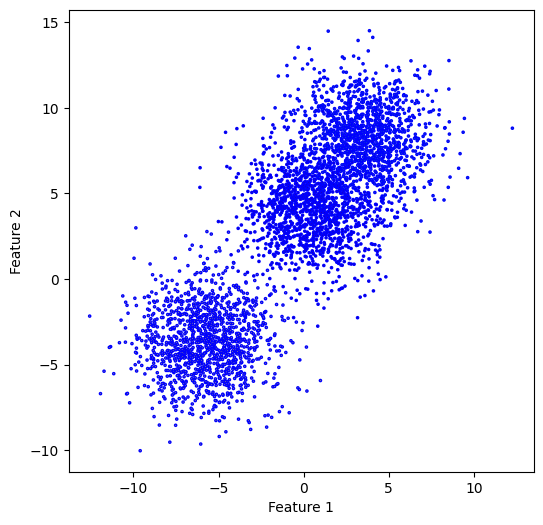

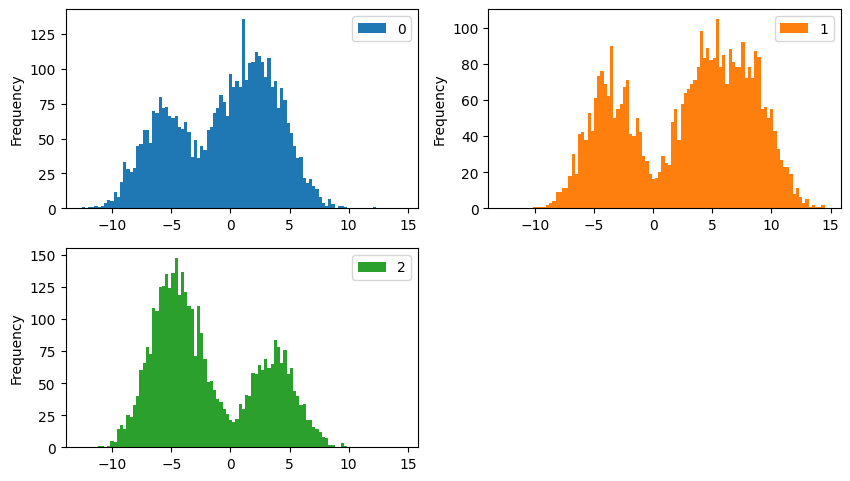

{'n_neighbors': np.int64(3)}
0.9887499999999999
Model accuracy score: 0.9890


In [7]:
X, y = make_blobs(n_samples = 4000, n_features = 3, centers = 3 ,cluster_std = 2, random_state = 80)
print('X(Features):')
print(X)
print('\nShape of X:')
print(X.shape)

print('\ny (Target/Class):')
print(y)
print('\n Shape of y:')
print(y.shape)

 #plot
plt.figure(figsize = (6,6))
plt.scatter(X[:,0], X[:,1], c=y, marker= '.', s=10, edgecolors='blue')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()


df = pd.DataFrame(X)
df.head()
plt.rcParams['figure.figsize']=(10,15)
df.plot(kind='hist', bins=100, subplots=True, layout=(5,2), sharex=False, sharey=False)
plt.show()

#scatter plot answers-How are my classes distributed based on Feature 1 and Feature 2?
#histogram --Distribution of each feature individually
'''The first step is to figure out the k. The calculation of the K value varies greatly depending on the situation.
The default value of K when using the Scikit-Learn Library is 5 and the default distance metric used is Euclidean.'''


#Tuning the Model to Get High K Nearest Neighbor Accuracy

from sklearn.model_selection import GridSearchCV
param_grid = {'n_neighbors':np.arange(1,4)}

knn = KNeighborsClassifier()
knn_cv= GridSearchCV(knn,param_grid,cv=5)
knn_cv.fit(X,y)

print(knn_cv.best_params_)
print(knn_cv.best_score_)
#train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 80)
# instantiate the model
knn = KNeighborsClassifier(n_neighbors=3)

# fit the model to the training set
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print('Model accuracy score: {0:0.4f}'. format(accuracy_score(y_test, y_pred)))

#We increased the number of neighbours from 1 to 4, and the model performed best at k=3.